# Rapport d'Analyse : Déterminants du Vote et Gentrification

**Auteurs :** Isaline JOUVE, Romain RATAJCZYK, Vincent VASYLCHENKO

## 1. Contexte et Objectifs
Les élections municipales de 2020 ont été marquées par une poussée écologiste dans les grandes villes et une abstention record. Ce projet vise à comprendre si ce vote est corrélé à des dynamiques de **gentrification** (évolution des revenus, des cadres, de l'éducation).

Nous croisons ici les données électorales (Ministère de l'Intérieur) et socio-économiques (INSEE) pour répondre à la problématique :
> *Les dynamiques socio-démographiques locales (gentrification) permettent-elles de prédire l'évolution du vote de gauche et écologiste ?*

Dans toute cette étude, nous nous intéressons aux résultats obtenus par le "bloc de gauche" aux élections municipales de 2014 et 2020. 
Nous considérons ici que ce bloc correspond à au groupe Europe Ecologie-Les Verts (LVEC), au groupe Ecologiste (LECO), au groupe Union de la Gauche (LUG), au groupe Divers Gauche (LDVG), au groupe (LSOC) et au groupe Liste du Parti de Gauche (LPG).

## Exécution du code

#### Installation automatique des dépendances si manquantes

In [1]:
# Installation automatique des dépendances si manquantes
! pip install -r "required_libraries.txt"

In [ ]:
# Étape 1 : Préparation des données et statistiques descriptives
%run "./notebooks/data_preparation.ipynb"

/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '5d2f7dc3' detected. Corrected to 'a305122b'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '6ddd9105' detected. Corrected to '3594556a'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id 'd3a2c9f7' detected. Corrected to '7d4a478d'.
  validate(nb)
/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '40fd2b

## Objectif 
Ce code effectue le premier traitement des bases de données qui seront utilisées pour ce projet. Il agrège dans un premier temps les bases de données produites par l'INSEE :
* Revenus et pauvreté des ménages
* Revenus localisés sociaux et fiscaux
* Diplômes-Formation

et dans un deuxième temps ajoute les résultats des élections présidentielles et communales de 2014, 2017, 2020 et 2022 qui ont été mis en forme dans le code "Data formatting".

Le code totalement reproductible est particulièrement lourd à exécuter. Aussi, le script vérifie 
si les données sont déjà chargées en mémoire (session active) ou si le fichier final est déjà présent (disponible sur le dépôt Git).
Si ces conditions sont remplies, l'étape de préparation est ignorée pour fluidifier la lecture du notebook.
Mais ce code le génère si besoin (pour vérifier la réplicabilité par exemple si vous le souhaitez !)

##### Chargement/Rechargement des données brutes...

- Chargement Population...


/tmp/ipykernel_9431/86269345.py:56: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pop_2020 = pd.read_csv(os.path.join(RAW_INSEE_DIR, files_insee['pop_2020']), sep=';', dtype={'COM': str})


- Chargement Diplômes...


/tmp/ipykernel_9431/86269345.py:63: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_diplo_2020 = pd.read_csv(os.path.join(RAW_INSEE_DIR, files_insee['diplo_2020']), sep=';', header=0, dtype={'COM': str})


- Chargement Revenus...


In [ ]:
# Étape 2 : Géoreprésentation des données des élections municipales
%run "./notebooks/Geo representation.ipynb"


In [ ]:
# Étape 3 : Régressions et Statistiques
%run "./notebooks/regression_statsmodel.ipynb"


/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


# Exploration Machine Learning et ACP

Cette section complète l'approche économétrique classique par des méthodes de Machine Learning et d'analyse
 multivariée, afin d'exploiter leurs complémentarités interprétatives et prédictives.

La **régression linéaire (OLS)** est mobilisée principalement pour l'analyse du sens des relations entre 
variables explicatives et vote, à travers le signe et l'ordre de grandeur des coefficients estimés. 
Elle fournit un cadre interprétable permettant d'identifier les effets marginaux moyens.

Le **Random Forest**, fondé sur l'agrégation d'arbres de décision entraînés sur des sous-échantillons 
aléatoires, est utilisé pour établir une hiérarchie des déterminants du vote, à partir de leur contribution 
à la réduction de l'erreur de variance. Il permet de capter des non-linéarités, interactions et effets de seuil.

La comparaison des coefficients de détermination (R²) constitue un élément central de l'analyse. Un R² 
plus élevé pour le Random Forest par rapport à l'OLS indique que la relation entre caractéristiques 
socio-économiques et comportement électoral ne se limite pas à des effets linéaires, mais repose sur des structures non linéaires indispensables à une prédiction correcte du vote.

Enfin, l'**Analyse en Composantes Principales (ACP)** est utilisée en complément afin de visualiser
 l'espace sociologique des communes et de synthétiser la structure des corrélations entre les variables 
explicatives.


### Application du Random Forest

R² Random Forest: 0.8075

Importance des variables :
score_gauche_pres_2017    0.856416
pct_sup_2022              0.081402
log_pop_2022              0.042223
log_med_19                0.019960
dtype: float64


R² moyen : 0.7303 (+/- 0.0272)


### Apports et limites du Random Forest

La standardisation des variables ne constitue pas un enjeu pour le Random Forest, celui-ci étant invariant
au changement d'échelle. 
Le réglage conjoint de la profondeur des arbres et du nombre d'estimateurs permet d'atteindre un compromis 
satisfaisant biais-variance, garantissant la stabilité des résultats.

Le gain d'environ 7 points de R² par rapport à la régression linéaire indique que le Random Forest parvient
à capter des **effets non linéaires et des effets de seuil** absents du cadre OLS. Par exemple, l'impact du 
niveau de diplôme sur le vote apparaît conditionné à des seuils démographiques ou contextuels, effets que 
l'OLS tend à lisser en les ramenant à un effet moyen.

Toutefois, malgré cette amélioration explicative, le Random Forest n'apporte pas de gain prédictif décisif 
par rapport à l'OLS, les niveaux de R² restant proches. Ce constat suggère que le comportement électoral 
étudié demeure largement structuré par une inertie linéaire dominante, rendant toute complexification
excessive du modèle peu justifiée au regard du rasoir d'Ockham.

L'analyse de l'importance des variables révèle enfin une domination écrasante du **score électoral passé 
(score_2017)**, qui concentre environ 85,6 % de la contribution explicative, confirmant que le vote 
observé relève avant tout d'une **reproduction géographique et historique**. Parmi les variables socio-économiques, 
le **niveau de diplôme** apparaît comme un déterminant 
plus puissant du vote de gauche que le revenu, avec une contribution relative nettement supérieure 
(8,1 % contre 1,9 %).



## Analyse des effets non linéaires : Partial Dependence Plots (PDP)

Pour mettre en évidence les **effets non linéaires et les seuils** identifiés par le Random Forest, 
nous utilisons les *Partial Dependence Plots (PDP)*.  

Ces graphiques permettent de visualiser l'effet marginal moyen d'une variable explicative sur la 
prédiction du modèle, en isolant son impact des autres variables. Cela est particulièrement utile pour 
détecter :
- des seuils, par exemple lorsque l'effet du niveau de diplôme sur le vote n'apparaît qu'à partir d'une 
certaine densité de population,
- des zones de plateau ou de saturation,
- des interactions implicites, où la pente change selon la valeur d'une autre variable.

L'interprétation des PDP complète ainsi l'importance des variables, en montrant non seulement quelles variables comptent, mais comment 
elles influencent la prédiction à différents niveaux.


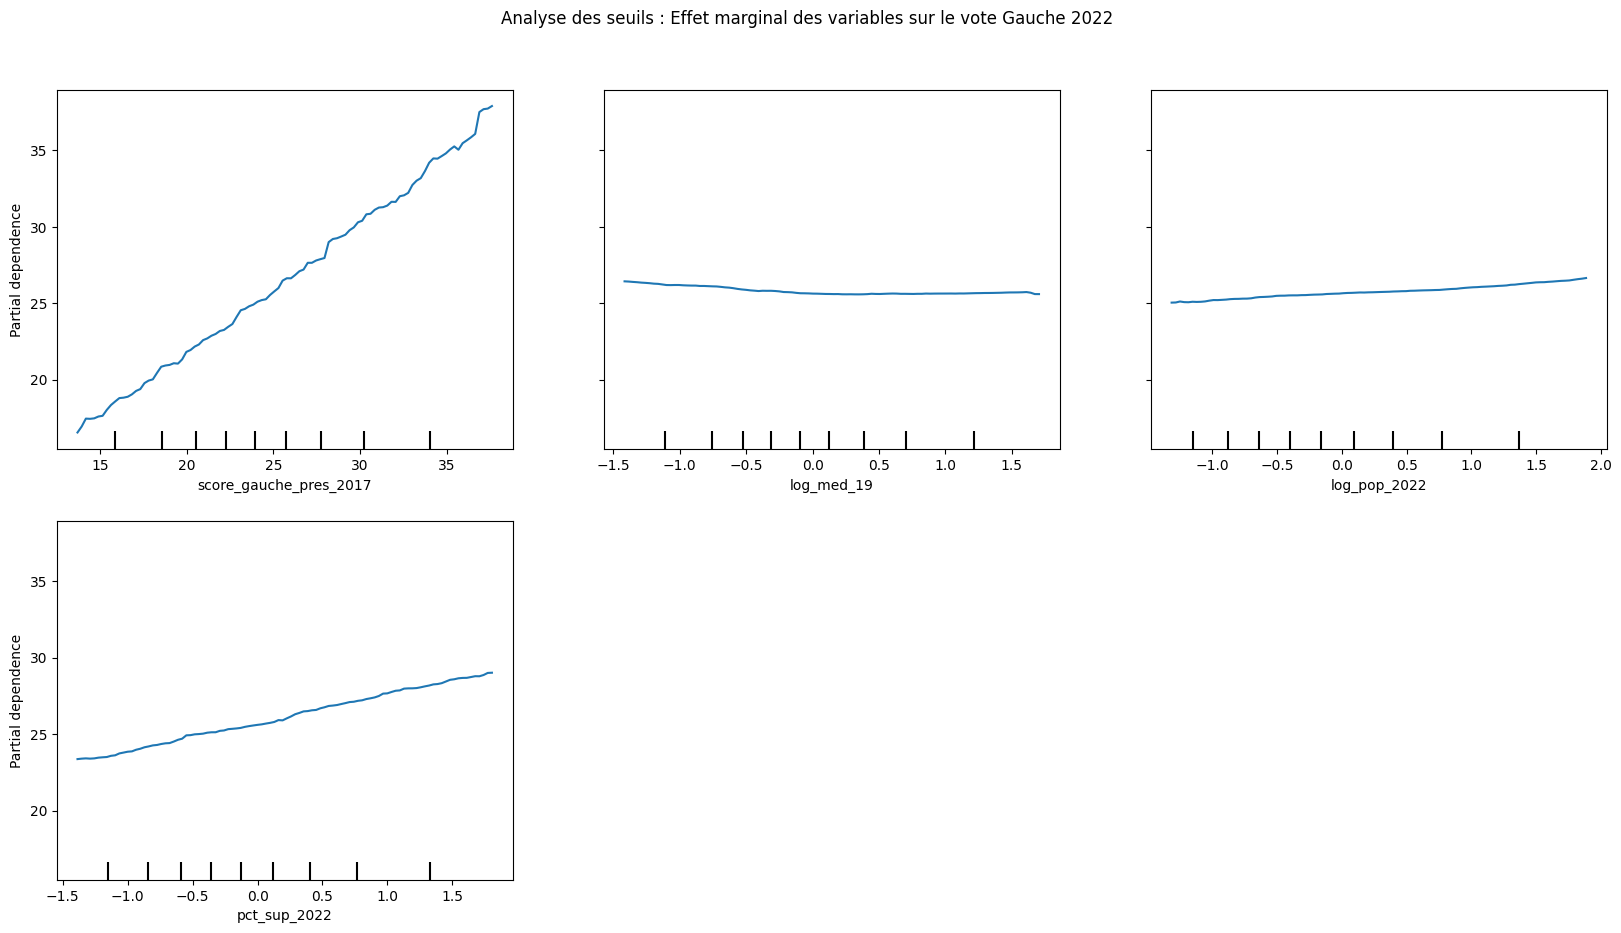


### Analyse des Graphiques de Dépendance Partielle (PDP)

Les *Partial Dependence Plots* permettent d'interpréter le modèle du Random Forest en isolant l'effet marginal de chaque variable.
 Ils révèlent des dynamiques que la régression linéaire lisse ou ignore.

* Inertie du vote (Score 2017) : La relation est fortement linéaire et positive. Cela confirme une 
dépendance au sentier : l'historique électoral reste le déterminant principal, témoignant de la stabilité 
de l'ancrage territorial des partis.

* Effet de taille (Log Population) : Contrairement à une approche linéaire, on observe ici des effets de 
seuil. La courbe permet d'identifier précisément le point de bascule démographique (le "gradient urbain") 
à partir duquel la probabilité de vote pour le bloc de gauche augmente significativement.

* Niveau de vie (Revenu médian) : La relation est souvent non-linéaire (en cloche). Le soutien au bloc 
gauche/écologiste tend à être plus faible aux deux extrêmes du spectre économique (quartiers très 
défavorisés et communes très aisées), trouvant son maximum au sein des classes moyennes intermédiaires 
et supérieures.
* Capital culturel (Diplômés du supérieur) : La courbe met en évidence un "effet d'entraînement" 
. Au-delà d'une certaine concentration de diplômés, le vote progresse plus rapidement,
 validant l'hypothèse d'une recomposition politique fondée sur des clivages éducatifs plutôt que purement
 matériels.

Ces non-linéarités et effets de saturation démontrent que les déterminants socio-économiques n'agissent 
pas de manière uniforme sur l'ensemble du territoire.


### Cartographie des Résidus : Analyse Spatiale de l'Erreur

La cartographie des résidus consiste à projeter spatialement l'écart entre le vote réel et le vote prédit par notre modèle.

L'objectif est de détecter une éventuelle "autocorrélation spatiale" des erreurs :
* Si les résidus sont répartis de manière aléatoire sur le territoire, cela valide la robustesse du modèle :
 les variables socio-économiques introduites (revenus, densité, diplômes) suffisent à expliquer la géographie du vote.
* Si les résidus apparaissent groupés géographiquement (des "tâches" de couleurs uniformes sur des 
régions entières), cela indique que le modèle souffre d'un biais de variable omise. Cela signifie qu'une 
dimension non prise en compte par nos données (facteur culturel, historique, ou présence d'un leader local)
 joue un rôle déterminant dans ces territoires.

In [ ]:

# Étape 4 : Exploration Machine Learning
%run "./notebooks/ML_exploration.ipynb"


# Conclusion Générale

Ce projet a pris racine dans la volonté d'expliquer ressorts de la "vague verte" et plus largement de la dynamique 
du bloc de gauche lors des élections municipales de 2020. En croisant des données électorales et socio-économiques
à l'échelle communale, notre analyse a cherché à dépasser le simple constat électoral pour interroger les 
mutations structurelles du vote en France, notamment au prisme de la gentrification.

**1. La validation des déterminants sociologiques**

L'approche économétrique a confirmé que la recomposition politique actuelle est fortement corrélée aux variables de 
la "nouvelle sociologie urbaine". La densité de population et la part des diplômés du supérieur apparaissent comme les 
vecteurs les plus puissants du vote écologiste et de gauche. L'analyse en première différence a permis 
de valider une dynamique causale : ce n'est pas seulement le niveau de richesse qui détermine le vote, 
mais bien la transformation sociologique d'un territoire (arrivée de cadres, élévation du niveau de diplôme) qui favorise 
la bascule politique.

**2. Au-delà des modèles linéaires : l'apport du Machine Learning**

L'intégration des modèles de Random Forest a permis d'affiner cette lecture en révélant l'existence d'effets de 
seuil. Le vote pour le bloc de gauche ne progresse pas de manière linéaire ; il s'accélère une fois atteints certains 
paliers de densité ou de concentration de capital culturel. Ces non-linéarités suggèrent qu'il existe une "masse critique" 
sociologique nécessaire pour qu'une commune change de couleur politique, validant l'hypothèse d'effets d'entraînement locaux.

**3. Les limites du déterminisme social**

Cependant, l'enseignement majeur de ce travail réside peut-être dans l'analyse des résidus. La cartographie des 
erreurs du modèle démontre que la sociologie ne fait pas l'élection. La persistance de clusters géographiques 
de sous-estimation (notamment en Bretagne et dans le Sud-Ouest) met en lumière une "dépendance au sentier". Dans ces territoires, 
l'héritage historique et culturel maintient le vote à gauche à des niveaux bien supérieurs à ce que la simple réalité économique prédirait.

**4. Vers une nouvelle géographie électorale**

En conclusion, si la gentrification et l'élévation du niveau d'éducation sont des moteurs indéniables du vote EELV/Gauche, 
elles ne peuvent occulter une fracture territoriale plus profonde. Nos résultats illustrent la polarisation croissante entre
 des centres urbains intégrés, où le vote progressiste se consolide sur des bases culturelles, et des périphéries ou des zones 
industrielles (Hauts-de-France, Grand Est) où le modèle peine à prédire le recul de la gauche au profit du Rassemblement National.
 L'analyse suggère ainsi que le clivage gauche-droite traditionnel s'efface progressivement au profit d'une opposition entre lieux, 
structurée par le rapport à la métropolisation et l'ancrage historique local.